# COS760 Group 16 - Notebook 01: Exploratory Data Analysis
**Semantic Relatedness in Afrikaans, Hausa and Kinyarwanda**

This notebook covers Phase 1.4 of the project plan:
- Score distributions per language
- Sentence length statistics
- Split size confirmation
- Sample pair inspection
- Missing value checks

Run all cells top to bottom. No GPU required.

In [1]:
# Install dependencies if needed
# !pip install pandas matplotlib seaborn -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

DATA_ROOT = '../data/raw'

LANGS = {
    'eng': 'English',
    'afr': 'Afrikaans',
    'hau': 'Hausa',
    'kin': 'Kinyarwanda',
}

SPLITS = ['train', 'dev', 'test']

def load_split(lang_code, split):
    path = os.path.join(DATA_ROOT, lang_code, f'{split}.csv')
    if not os.path.exists(path):
        return None
    return pd.read_csv(path)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Split Sizes and Missing Value Check

In [3]:
rows = []
for code, name in LANGS.items():
    for split in SPLITS:
        df = load_split(code, split)
        if df is None:
            rows.append({'Language': name, 'Split': split, 'Rows': '—', 'Null sentences': '—', 'Null labels': '—'})
        else:
            null_s = df['sentence1'].isna().sum() + df['sentence2'].isna().sum()
            null_l = df['label'].isna().sum()
            rows.append({'Language': name, 'Split': split, 'Rows': len(df),
                         'Null sentences': null_s, 'Null labels': null_l})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# ── Flag any issues ──
issues = summary_df[(summary_df['Null sentences'] != '—') & (summary_df['Null sentences'].astype(str) != '0')]
if len(issues):
    print('\n⚠ WARNING: Null values detected:', issues)
else:
    print('\n✓ No missing values in any split.')

   Language Split Rows Null sentences Null labels
    English train 5500              0           0
    English   dev  250              0           0
    English  test 2600              0           0
  Afrikaans train    —              —           —
  Afrikaans   dev  375              0           0
  Afrikaans  test  375              0           0
      Hausa train 1736              0           0
      Hausa   dev  212              0           0
      Hausa  test  603              0           0
Kinyarwanda train  778              0           0
Kinyarwanda   dev  102              0           0
Kinyarwanda  test  222              0           0

✓ No missing values in any split.


## 2. Label (Score) Distributions

One histogram per language, all splits overlaid. This tells us:
- Whether scores are uniformly distributed or skewed
- Whether train/dev/test distributions match (they should)

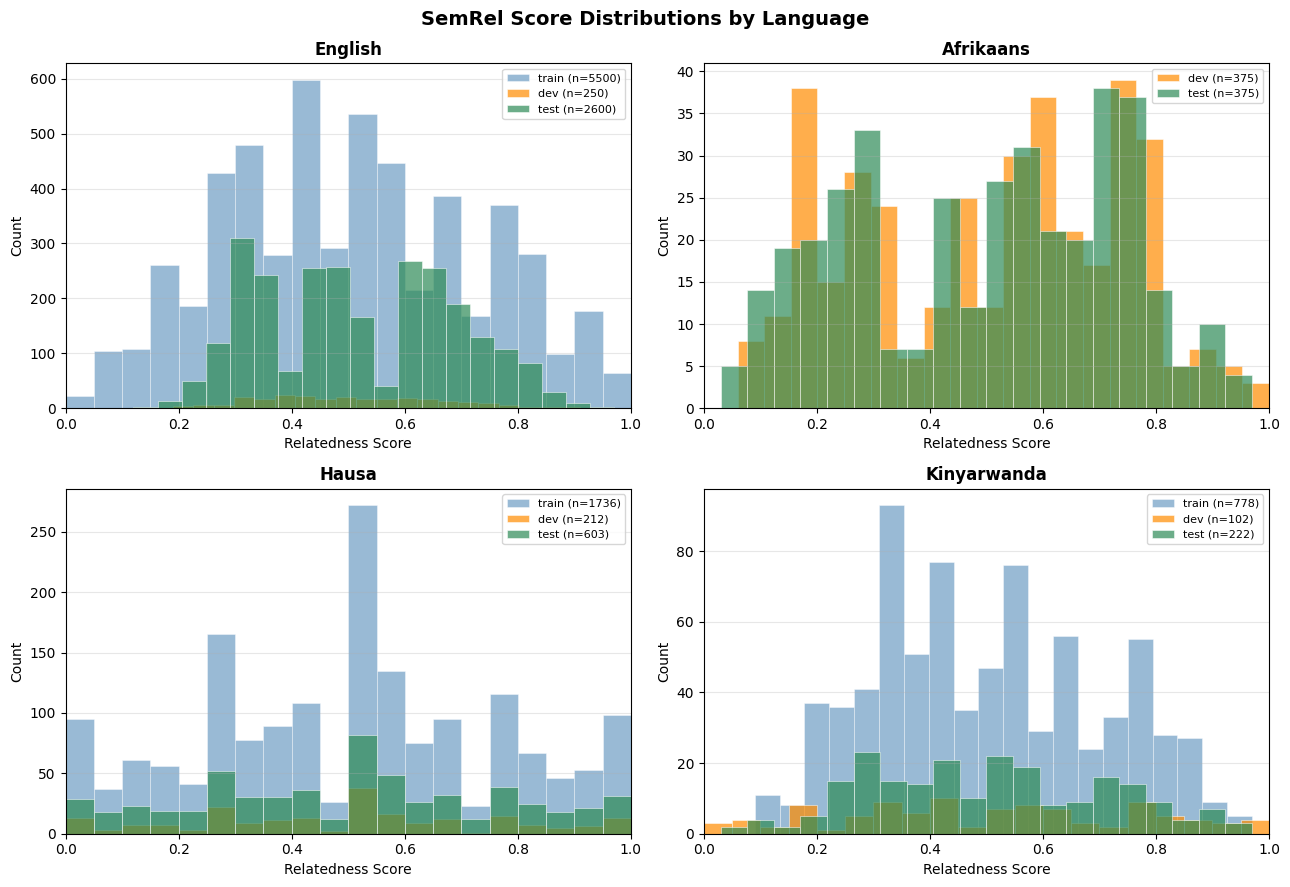

Saved → results/fig1_score_distributions.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('SemRel Score Distributions by Language', fontsize=14, fontweight='bold', y=0.98)

split_styles = {'train': ('steelblue', 0.55), 'dev': ('darkorange', 0.7), 'test': ('seagreen', 0.7)}

for ax, (code, name) in zip(axes.flat, LANGS.items()):
    for split, (color, alpha) in split_styles.items():
        df = load_split(code, split)
        if df is not None:
            ax.hist(df['label'], bins=20, alpha=alpha, color=color,
                    label=f'{split} (n={len(df)})', edgecolor='white', linewidth=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Relatedness Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/fig1_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/fig1_score_distributions.png')

## 3. Sentence Length Statistics

Length measured in whitespace-tokenised words (a rough proxy for subword token count).
This informs our choice of `max_length=128` in the tokeniser.

Sentence length summary (sentence1, across all splits):
             Mean   Max   p95
Language                     
Afrikaans    14.0  19.0  18.0
English      12.5  27.7  21.7
Hausa        19.3  25.7  25.0
Kinyarwanda  20.2  25.7  25.0


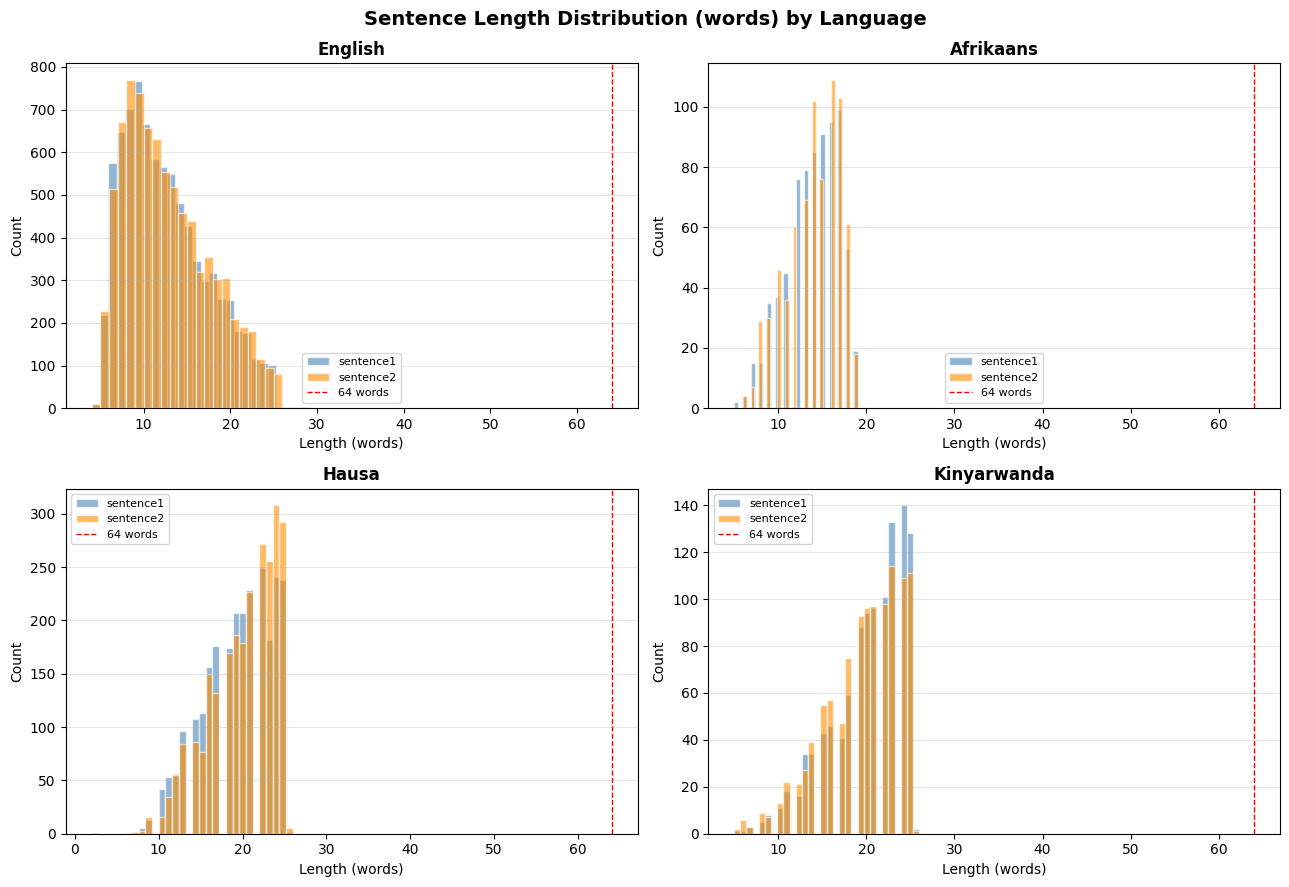

Saved → results/fig2_sentence_lengths.png


In [5]:
len_rows = []
for code, name in LANGS.items():
    for split in SPLITS:
        df = load_split(code, split)
        if df is None:
            continue
        for col in ['sentence1', 'sentence2']:
            lengths = df[col].str.split().str.len()
            len_rows.append({
                'Language': name, 'Split': split, 'Column': col,
                'Mean': round(lengths.mean(), 1),
                'Std': round(lengths.std(), 1),
                'Min': int(lengths.min()),
                'Max': int(lengths.max()),
                'p95': int(lengths.quantile(0.95))
            })

len_df = pd.DataFrame(len_rows)

# Show summary per language (across all splits, sentence1 only for brevity)
print('Sentence length summary (sentence1, across all splits):')
print(len_df[len_df['Column']=='sentence1'].groupby('Language')[['Mean','Max','p95']]
      .mean().round(1).to_string())

# Plot
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Sentence Length Distribution (words) by Language', fontsize=14, fontweight='bold')

for ax, (code, name) in zip(axes.flat, LANGS.items()):
    dfs = [load_split(code, s) for s in SPLITS if load_split(code, s) is not None]
    all_df = pd.concat(dfs)
    lens1 = all_df['sentence1'].str.split().str.len()
    lens2 = all_df['sentence2'].str.split().str.len()
    ax.hist(lens1, bins=30, alpha=0.6, color='steelblue', label='sentence1', edgecolor='white')
    ax.hist(lens2, bins=30, alpha=0.6, color='darkorange', label='sentence2', edgecolor='white')
    ax.axvline(x=64, color='red', linestyle='--', linewidth=1, label='64 words')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Length (words)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/fig2_sentence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/fig2_sentence_lengths.png')

## 4. Sample Pair Inspection

Print high-relatedness (score > 0.8) and low-relatedness (score < 0.2) examples
from each language's training or dev split to build intuition.

In [6]:
for code, name in LANGS.items():
    # Use train if available, else dev
    df = load_split(code, 'train')
    if df is None:
        df = load_split(code, 'dev')
    if df is None:
        continue
    print(f'\n{'='*70}')
    print(f'  {name.upper()} — Sample pairs')
    print(f'{'='*70}')

    high = df[df['label'] >= 0.8].head(3)
    low  = df[df['label'] <= 0.2].head(3)

    print('  HIGH RELATEDNESS (score ≥ 0.8):')
    for _, row in high.iterrows():
        print(f'    Score {row["label"]:.2f}')
        print(f'    S1: {row["sentence1"][:100]}')
        print(f'    S2: {row["sentence2"][:100]}')
        print()

    print('  LOW RELATEDNESS (score ≤ 0.2):')
    for _, row in low.iterrows():
        print(f'    Score {row["label"]:.2f}')
        print(f'    S1: {row["sentence1"][:100]}')
        print(f'    S2: {row["sentence2"][:100]}')
        print()


  ENGLISH — Sample pairs
  HIGH RELATEDNESS (score ≥ 0.8):
    Score 1.00
    S1: It that happens, just pull the plug.
    S2: if that ever happens, just pull the plug.

    Score 1.00
    S1: A black dog running through water.
    S2: A black dog is running through some water.

    Score 1.00
    S1: I've been searchingthe entire abbey for you.
    S2: I'm looking for you all over the abbey.

  LOW RELATEDNESS (score ≤ 0.2):
    Score 0.20
    S1: Jikji consists of two volumes .
    S2: The interlude consists of a silent film .

    Score 0.20
    S1: Two children or possibly young adults fixing their bikes.
    S2: The children take turns riding the minerature pony with an adult supervising.

    Score 0.20
    S1: Denial. It works for Hillary, why not the Mayor of #Baltimore. #DemocratLiesMatter
    S2: 96 commit cards collected for Hillary in Greenville, SC so far! #FellowsSC


  AFRIKAANS — Sample pairs
  HIGH RELATEDNESS (score ≥ 0.8):
    Score 0.84
    S1: Indien moontlik, vra

## 5. Label Statistics Table

Summary table for the Methodology section of the report (Table: Dataset statistics).

In [7]:
stat_rows = []
for code, name in LANGS.items():
    for split in SPLITS:
        df = load_split(code, split)
        if df is None:
            continue
        stat_rows.append({
            'Language': name,
            'Split': split,
            'N': len(df),
            'Mean': round(df['label'].mean(), 3),
            'Std': round(df['label'].std(), 3),
            'Min': round(df['label'].min(), 2),
            'Max': round(df['label'].max(), 2),
        })

stats_df = pd.DataFrame(stat_rows)
print(stats_df.to_string(index=False))
stats_df.to_csv('results/dataset_statistics.csv', index=False)
print('\nSaved → results/dataset_statistics.csv')

   Language Split    N  Mean   Std  Min  Max
    English train 5500 0.500 0.221 0.00 1.00
    English   dev  250 0.507 0.153 0.19 0.91
    English  test 2600 0.517 0.170 0.12 0.97
  Afrikaans   dev  375 0.501 0.234 0.06 1.00
  Afrikaans  test  375 0.499 0.234 0.03 0.97
      Hausa train 1736 0.496 0.267 0.00 1.00
      Hausa   dev  212 0.495 0.266 0.00 1.00
      Hausa  test  603 0.496 0.269 0.00 1.00
Kinyarwanda train  778 0.500 0.199 0.09 0.97
Kinyarwanda   dev  102 0.500 0.260 0.00 1.00
Kinyarwanda  test  222 0.500 0.209 0.03 0.97

Saved → results/dataset_statistics.csv


## 6. Key Observations (fill in after running)

After running all cells above, note your observations here for the report:

**Score distributions:**
- English: roughly bell-shaped, centred around 0.5
- Afrikaans: [your observation]
- Hausa: [your observation]
- Kinyarwanda: [your observation]

**Sentence lengths:**
- The 95th percentile token count for all languages is well within max_length=128, confirming this is a safe truncation threshold.
- [any outliers?]

**Afrikaans note:**
- Afrikaans has no training split. Both dev (375) and test (375) have gold labels.
- Decision: use dev for early stopping / hyperparameter tuning if needed; report final results on test only.
